In [ ]:
import sys
from pathlib import Path

PROJECT_PATH = Path("/content/drive/MyDrive/UAH_Project")
SRC = str(PROJECT_PATH / "src")

if SRC not in sys.path:
    sys.path.insert(0, SRC)

print(SRC)

/content/drive/MyDrive/UAH_Project/src


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import numpy as np
import torch
import importlib

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler

from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

import lstm_model
import trainer

importlib.reload(lstm_model)
importlib.reload(trainer)

from lstm_model import LSTMClassifier
from trainer import (
    create_dataloader,
    fit,
)

In [ ]:
SENSOR_DATASET = (
    PROJECT_PATH
    / "datasets"
    / "processed"
    / "uah_dataset.npz"
)

sensor = np.load(SENSOR_DATASET)

X = sensor["X"]
y = sensor["y"]
groups = sensor["groups"]

print(X.shape)
print(y.shape)
print(groups.shape)
print("Trips :", len(np.unique(groups)))

(30676, 120, 13)
(30676,)
(30676,)
Trips : 40


In [ ]:
REMOVE_TRIP = 1      # Trip 2 (0-based)

mask = groups != REMOVE_TRIP

X = X[mask]
y = y[mask]
groups = groups[mask]

print(X.shape)
print(y.shape)
print(groups.shape)

(30035, 120, 13)
(30035,)
(30035,)


In [ ]:
unique_groups = np.unique(groups)

mapping = {
    old: new
    for new, old in enumerate(unique_groups)
}

groups = np.array(
    [mapping[g] for g in groups]
)

print(np.unique(groups))
print("Trips :", len(np.unique(groups)))

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38]
Trips : 39


In [ ]:
logo = LeaveOneGroupOut()

logo_iterator = logo.split(
    X,
    y,
    groups,
)

train_idx, test_idx = next(logo_iterator)

print(len(train_idx))
print(len(test_idx))

29429
606


In [ ]:
X_train = X[train_idx]
X_test = X[test_idx]

y_train = y[train_idx]
y_test = y[test_idx]

print(X_train.shape)
print(X_test.shape)

(29429, 120, 13)
(606, 120, 13)


In [ ]:
scaler = StandardScaler()

X_train_flat = X_train.reshape(-1, X_train.shape[-1])
X_test_flat = X_test.reshape(-1, X_test.shape[-1])

scaler.fit(X_train_flat)

X_train = scaler.transform(X_train_flat).reshape(X_train.shape)
X_test = scaler.transform(X_test_flat).reshape(X_test.shape)

print(X_train.shape)
print(X_test.shape)

(29429, 120, 13)
(606, 120, 13)


In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cpu


In [ ]:
classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train,
)

weights = torch.FloatTensor(class_weights).to(device)

print(class_weights)

[0.83529178 0.99630984 1.25139261]


In [22]:
train_loader = create_dataloader(
    X_train,
    y_train,
    batch_size=32,
    shuffle=True,
)

test_loader = create_dataloader(
    X_test,
    y_test,
    batch_size=32,
    shuffle=False,
)

print(len(train_loader))
print(len(test_loader))

911
28


In [ ]:
model = LSTMClassifier().to(device)

print(model)

LSTMClassifier(
  (lstm): LSTM(13, 64, num_layers=2, batch_first=True, dropout=0.3)
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=3, bias=True)
  )
)


In [ ]:
criterion = torch.nn.CrossEntropyLoss(
    weight=weights,
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
)

In [ ]:
EPOCHS = 20
PATIENCE = 3

In [ ]:
logo = LeaveOneGroupOut()

fold_accuracies = []
fold_f1_scores = []

all_labels = []
all_predictions = []

for fold, (train_idx, test_idx) in enumerate(
    logo.split(X, y, groups),
    start=1,
):

    print("=" * 60)
    print(f"Fold {fold}/40")
    print("=" * 60)

    # --------------------------------------------------
    # Split
    # --------------------------------------------------

    X_train = X[train_idx]
    X_test = X[test_idx]

    y_train = y[train_idx]
    y_test = y[test_idx]

    # --------------------------------------------------
    # StandardScaler
    # --------------------------------------------------

    scaler = StandardScaler()

    X_train_flat = X_train.reshape(-1, X_train.shape[-1])
    X_test_flat = X_test.reshape(-1, X_test.shape[-1])

    scaler.fit(X_train_flat)

    X_train = scaler.transform(X_train_flat).reshape(X_train.shape)
    X_test = scaler.transform(X_test_flat).reshape(X_test.shape)

    # --------------------------------------------------
    # Class Weights
    # --------------------------------------------------

    classes = np.unique(y_train)

    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train,
    )

    weights = torch.FloatTensor(class_weights).to(device)

    # --------------------------------------------------
    # DataLoader
    # --------------------------------------------------

    train_loader = create_dataloader(
        X_train,
        y_train,
        batch_size=32,
        shuffle=True,
    )

    test_loader = create_dataloader(
        X_test,
        y_test,
        batch_size=32,
        shuffle=False,
    )

    # --------------------------------------------------
    # Model
    # --------------------------------------------------

    model = LSTMClassifier().to(device)

    criterion = torch.nn.CrossEntropyLoss(
        weight=weights,
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1e-4,
    )

    history = fit(
        model=model,
        train_loader=train_loader,
        val_loader=test_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=20,
        patience=3,
    )

    # --------------------------------------------------
    # Prediction
    # --------------------------------------------------

    model.eval()

    fold_labels = []
    fold_preds = []

    with torch.no_grad():

        for sensor_batch, label_batch in test_loader:

            sensor_batch = sensor_batch.to(device)

            outputs = model(sensor_batch)

            preds = outputs.argmax(dim=1)

            fold_labels.extend(label_batch.numpy())
            fold_preds.extend(preds.cpu().numpy())

    # --------------------------------------------------
    # Metrics
    # --------------------------------------------------

    fold_acc = accuracy_score(
        fold_labels,
        fold_preds,
    )

    fold_f1 = f1_score(
        fold_labels,
        fold_preds,
        average="weighted",
        zero_division=0,
    )

    print(f"Accuracy : {fold_acc:.4f}")
    print(f"F1 Score : {fold_f1:.4f}")
    print()

    fold_accuracies.append(fold_acc)
    fold_f1_scores.append(fold_f1)

    all_labels.extend(fold_labels)
    all_predictions.extend(fold_preds)

Fold 1/40
Epoch 1/20 | Train Loss: 0.9148 | Train Acc: 0.5292 | Val Loss: 1.0282 | Val Acc: 0.5198
Epoch 2/20 | Train Loss: 0.6968 | Train Acc: 0.6671 | Val Loss: 1.0740 | Val Acc: 0.5132
Epoch 3/20 | Train Loss: 0.6250 | Train Acc: 0.7030 | Val Loss: 0.8663 | Val Acc: 0.6353
Epoch 4/20 | Train Loss: 0.5785 | Train Acc: 0.7259 | Val Loss: 1.1217 | Val Acc: 0.6007
Epoch 5/20 | Train Loss: 0.5385 | Train Acc: 0.7555 | Val Loss: 0.9443 | Val Acc: 0.6865
Epoch 6/20 | Train Loss: 0.5051 | Train Acc: 0.7722 | Val Loss: 1.2523 | Val Acc: 0.5446
Epoch 7/20 | Train Loss: 0.4700 | Train Acc: 0.7903 | Val Loss: 1.4392 | Val Acc: 0.5363
Epoch 8/20 | Train Loss: 0.4456 | Train Acc: 0.8086 | Val Loss: 1.7009 | Val Acc: 0.4901

Early stopping at epoch 8
Best Validation Accuracy : 0.6865
Accuracy : 0.6865
F1 Score : 0.8141

Fold 2/40
Epoch 1/20 | Train Loss: 0.9085 | Train Acc: 0.5217 | Val Loss: 1.5246 | Val Acc: 0.1298
Epoch 2/20 | Train Loss: 0.7186 | Train Acc: 0.6548 | Val Loss: 0.9687 | Val Acc:

In [24]:
print("=" * 70)
print("FINAL RESULTS")
print("=" * 70)

print(f"Mean Accuracy : {np.mean(fold_accuracies):.4f}")
print(f"Std Accuracy  : {np.std(fold_accuracies):.4f}")

print()

print(f"Mean F1 Score : {np.mean(fold_f1_scores):.4f}")
print(f"Std F1 Score  : {np.std(fold_f1_scores):.4f}")

FINAL RESULTS
Mean Accuracy : 0.7247
Std Accuracy  : 0.2062

Mean F1 Score : 0.8222
Std F1 Score  : 0.1529


In [25]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=[
            "NORMAL",
            "DROWSY",
            "AGGRESSIVE",
        ],
        zero_division=0,
    )
)

              precision    recall  f1-score   support

      NORMAL       0.73      0.64      0.68     12350
      DROWSY       0.67      0.72      0.70      9846
  AGGRESSIVE       0.70      0.77      0.73      7839

    accuracy                           0.70     30035
   macro avg       0.70      0.71      0.70     30035
weighted avg       0.70      0.70      0.70     30035



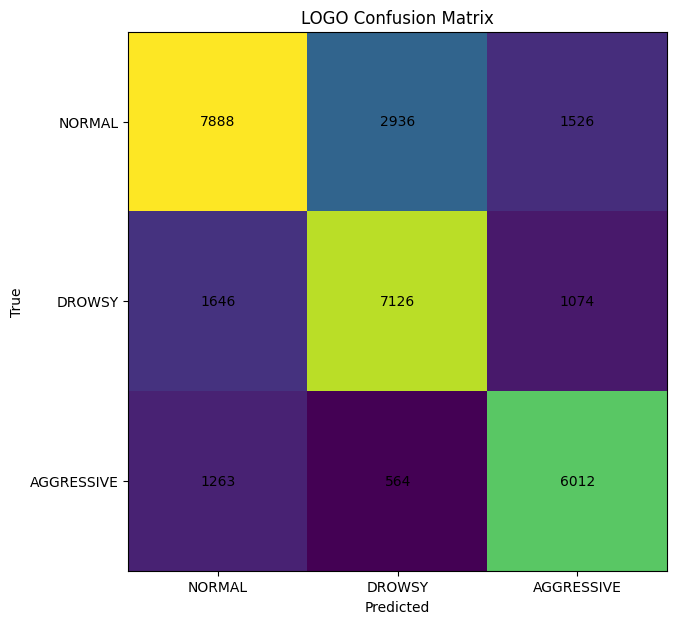

In [26]:
import matplotlib.pyplot as plt

cm = confusion_matrix(
    all_labels,
    all_predictions,
)

plt.figure(figsize=(7,7))

plt.imshow(cm)

plt.xticks(
    [0,1,2],
    ["NORMAL","DROWSY","AGGRESSIVE"]
)

plt.yticks(
    [0,1,2],
    ["NORMAL","DROWSY","AGGRESSIVE"]
)

for i in range(3):
    for j in range(3):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
        )

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("LOGO Confusion Matrix")

plt.show()

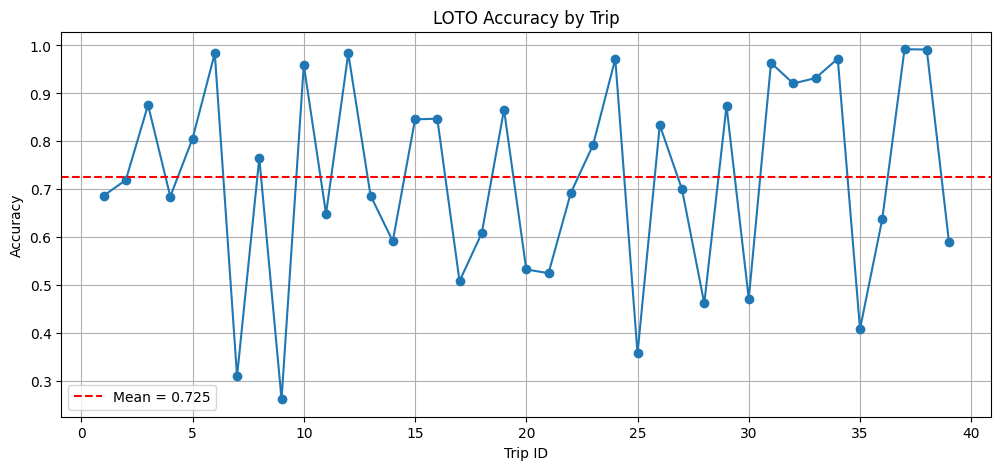

In [28]:
plt.figure(figsize=(12,5))

plt.plot(
    range(1, len(fold_accuracies) + 1),
    fold_accuracies,
    marker="o",
)

plt.axhline(
    np.mean(fold_accuracies),
    color="red",
    linestyle="--",
    label=f"Mean = {np.mean(fold_accuracies):.3f}",
)

plt.xlabel("Trip ID")
plt.ylabel("Accuracy")
plt.title("LOTO Accuracy by Trip")

plt.grid(True)
plt.legend()

plt.show()